2.Implement crack detection using ResNet/U-Net on a crack image dataset.

In [ ]:
!pip install kaggle ultralytics tensorflow opencv-python matplotlib scikit-image

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

unet = unet_model()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    131,200 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, cv2, glob
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

IMAGE_DIR = "/content/drive/MyDrive/crackforest/Images"
MASK_DIR  = "/content/drive/MyDrive/crackforest/Masks"

IMG_SIZE = 128
images, masks = [], []

image_paths = sorted(glob.glob(IMAGE_DIR + "/*.jpg"))
mask_paths  = sorted(glob.glob(MASK_DIR + "/*.png") + glob.glob(MASK_DIR + "/*.PNG"))

print("Found images:", len(image_paths))
print("Found masks :", len(mask_paths))

for img_path, mask_path in zip(image_paths, mask_paths):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

    mask = mask / 255.0
    mask = np.expand_dims(mask, -1)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks  = np.array(masks)

print("Loaded images array:", images.shape)
print("Loaded masks array :", masks.shape)


X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

unet.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

unet.save("unet_crackforest.h5")
print("Training complete.")


Found images: 118
Found masks : 118
Loaded images array: (118, 128, 128, 3)
Loaded masks array : (118, 128, 128, 1)
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.9851 - loss: 0.0537 - val_accuracy: 0.9853 - val_loss: 0.0481
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9854 - loss: 0.0516 - val_accuracy: 0.9848 - val_loss: 0.0487
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9877 - loss: 0.0402 - val_accuracy: 0.9854 - val_loss: 0.0459
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9868 - loss: 0.0440 - val_accuracy: 0.9857 - val_loss: 0.0458
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9862 - loss: 0.0465 - val_accuracy: 0.9857 - val_loss: 0.0452
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9853 - loss: 0.0488 - val_accuracy: 0.9859 - val_loss: 0.0446
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9870 - loss: 0.0411 - val_accuracy: 0.9859 - val_loss: 

Training complete.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step


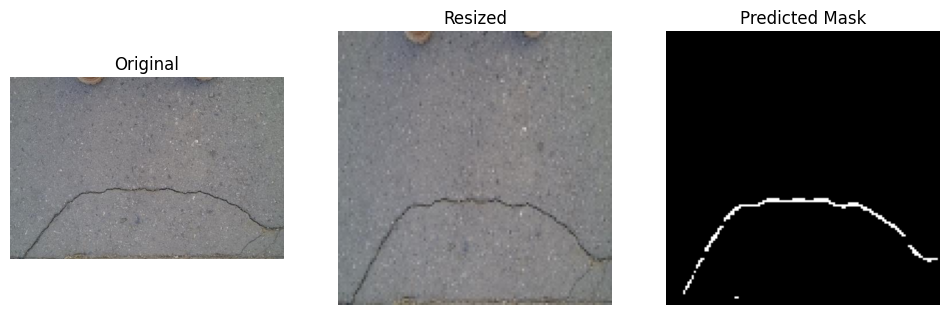

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import cv2
import glob
from tensorflow.keras.models import load_model

model = load_model("unet_crackforest.h5", compile=False)

IMG_SIZE = 128
IMAGE_DIR = "/content/drive/MyDrive/crackforest/Images"

test_img_path = np.random.choice(glob.glob(IMAGE_DIR + "/*.jpg"))

img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)) / 255.0

inp = np.expand_dims(img_resized, 0)
pred = model.predict(inp)[0]
pred_mask = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Resized"); plt.imshow(img_resized); plt.axis("off")
plt.subplot(1,3,3); plt.title("Predicted Mask"); plt.imshow(pred_mask.squeeze(), cmap="gray"); plt.axis("off")
plt.show()
